# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Adjust this path if your repo is stored elsewhere in Drive.
# PROJECT_ROOT = "/content/drive/MyDrive/Assignment1_2026"
PROJECT_ROOT = "/Users/tomnguyen/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/uni/2026/deep_learning/Assignment1_2026/"

In [2]:
# Install Python dependencies (run once per session)
!pip install -r '/Users/tomnguyen/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/uni/2026/deep_learning/Assignment1_2026/requirements.txt' -q
!python -m spacy download en

⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.1 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [3]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: /Users/tomnguyen/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/uni/2026/deep_learning/Assignment1_2026


---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [13]:
#from Tools.download import download_mini

#download_mini(data_dir="_data")

---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [14]:
from Tools.preproc import preprocess

preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)

Generating train examples…


100%|██████████| 150/150 [00:02<00:00, 54.18it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:00<00:00, 50.67it/s]


  10570 questions in total
Generating word embedding…


...

100%|██████████| 30293/30293 [00:04<00:00, 6891.60it/s]


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:01<00:00, 6553.17it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/


{'train_record_file': '_data/train.npz',
 'dev_record_file': '_data/dev.npz',
 'word_emb_file': '_data/word_emb.json',
 'char_emb_file': '_data/char_emb.json',
 'train_eval_file': '_data/train_eval.json',
 'dev_eval_file': '_data/dev_eval.json',
 'word2idx_file': '_data/word2idx.json',
 'char2idx_file': '_data/char2idx.json',
 'dev_meta_file': '_data/dev_meta.json'}

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.

In [5]:
from TrainTools.train import train

results = train(
    # ── data paths (must match preprocess outputs) ──────────────────────
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model",
    log_dir         = "_log",

    #num_steps  = 60000,
    #batch_size = 8,
    #seed       = 42,

    # # ── vanilla recipe: SGD, no scheduler, NLL loss ───────────────────────
    # optimizer_name = "sgd",
    # scheduler_name = "lambda",
    # loss_name      = "qa_nll",

    # ── training loop ────────────────────────────────────────────────────
    num_steps  = 10000,
    checkpoint = 500,
    batch_size = 8,
    accumulate_grad_steps = 4,
    seed = 42,
    val_num_batches = 0, # used on the train dataset (random batches), so it is really train-monitoring, not validation
    test_num_batches = 150,
    early_stop = 10,

    # ── optimizer hyperparameters ─────────────────────────────────────────────
    optimizer_name = "adam",
    scheduler_name = "cosine",
    loss_name = "qa_nll",
    
    learning_rate = 1e-3,
    beta1 = 0.9,
    beta2 = 0.999,
    eps = 1e-8,
    weight_decay = 3e-5,
    grad_clip = 1.0,
    warmup_steps = 1000,
    dropout = 0.15,
    d_model = 128,
    
)

print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")

  2%|▏         | 32/1500 [02:50<2:10:30,  5.33s/it]


KeyboardInterrupt: 

---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [ ]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model",
    log_dir       = "_log",
    ckpt_name     = "model.pt",
    loss_name     = "qa_nll",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")

100%|██████████| 1309/1309 [28:16<00:00,  1.30s/it]


TEST  loss 44.620523  F1 7.542209  EM 0.086001
F1: 7.5422  |  EM: 0.0860  |  Loss: 44.620523


## Experiment 1 — Scheduler Comparison

In [ ]:
from TrainTools.train import train

common = dict(
    train_npz="_data/train.npz",
    dev_npz="_data/dev.npz",
    word_emb_json="_data/word_emb.json",
    char_emb_json="_data/char_emb.json",
    train_eval_json="_data/train_eval.json",
    dev_eval_json="_data/dev_eval.json",
    save_dir="_model",
    log_dir="_log",

    # Match Section 3 baseline training recipe
    num_steps=10000,
    checkpoint=1500,
    batch_size=8,
    accumulate_grad_steps=4,
    seed=42,
    val_num_batches=0,
    test_num_batches=150,

    # Optimizer hyperparameters
    learning_rate=1e-3,
    beta1=0.8,
    beta2=0.999,
    eps=1e-7,
    weight_decay=3e-5,
    early_stop=10,

    optimizer_name="adam",
    loss_name="qa_ce",
    log_every_steps=10,
    track_cq_stats=True,
    save_step_metrics=True,
)

r_lambda = train(**common, scheduler_name="lambda", step_metrics_file="exp1_lambda_seed42.json")
r_cosine = train(**common, scheduler_name="cosine", step_metrics_file="exp1_cosine_seed42.json")
r_none   = train(**common, scheduler_name="none",   step_metrics_file="exp1_none_seed42.json")

  3%|▎         | 6/200 [00:32<17:33,  5.43s/it]


KeyboardInterrupt: 

,num_logged_steps,last_logged_step,early_loss_mean,early_loss_std,early_grad_mean,early_grad_max,early_cq_grad_mean,cq_var_pre1000,cq_var_post1000,nonfinite_events
scheduler,,,,,,,,,,
cosine,420,4200,10592.439456,5685.924827,8.718164e+12,8.070643e+14,3.109675e+12,0.003938,0.005261,0
lambda,580,5800,9725.807523,5510.167317,1.158130e+14,8.616645e+15,8.550688e+12,0.003541,0.005436,0
none,480,4800,10050.867447,9481.214228,3.470765e+11,2.220766e+13,1.969790e+11,0.004118,0.006099,0


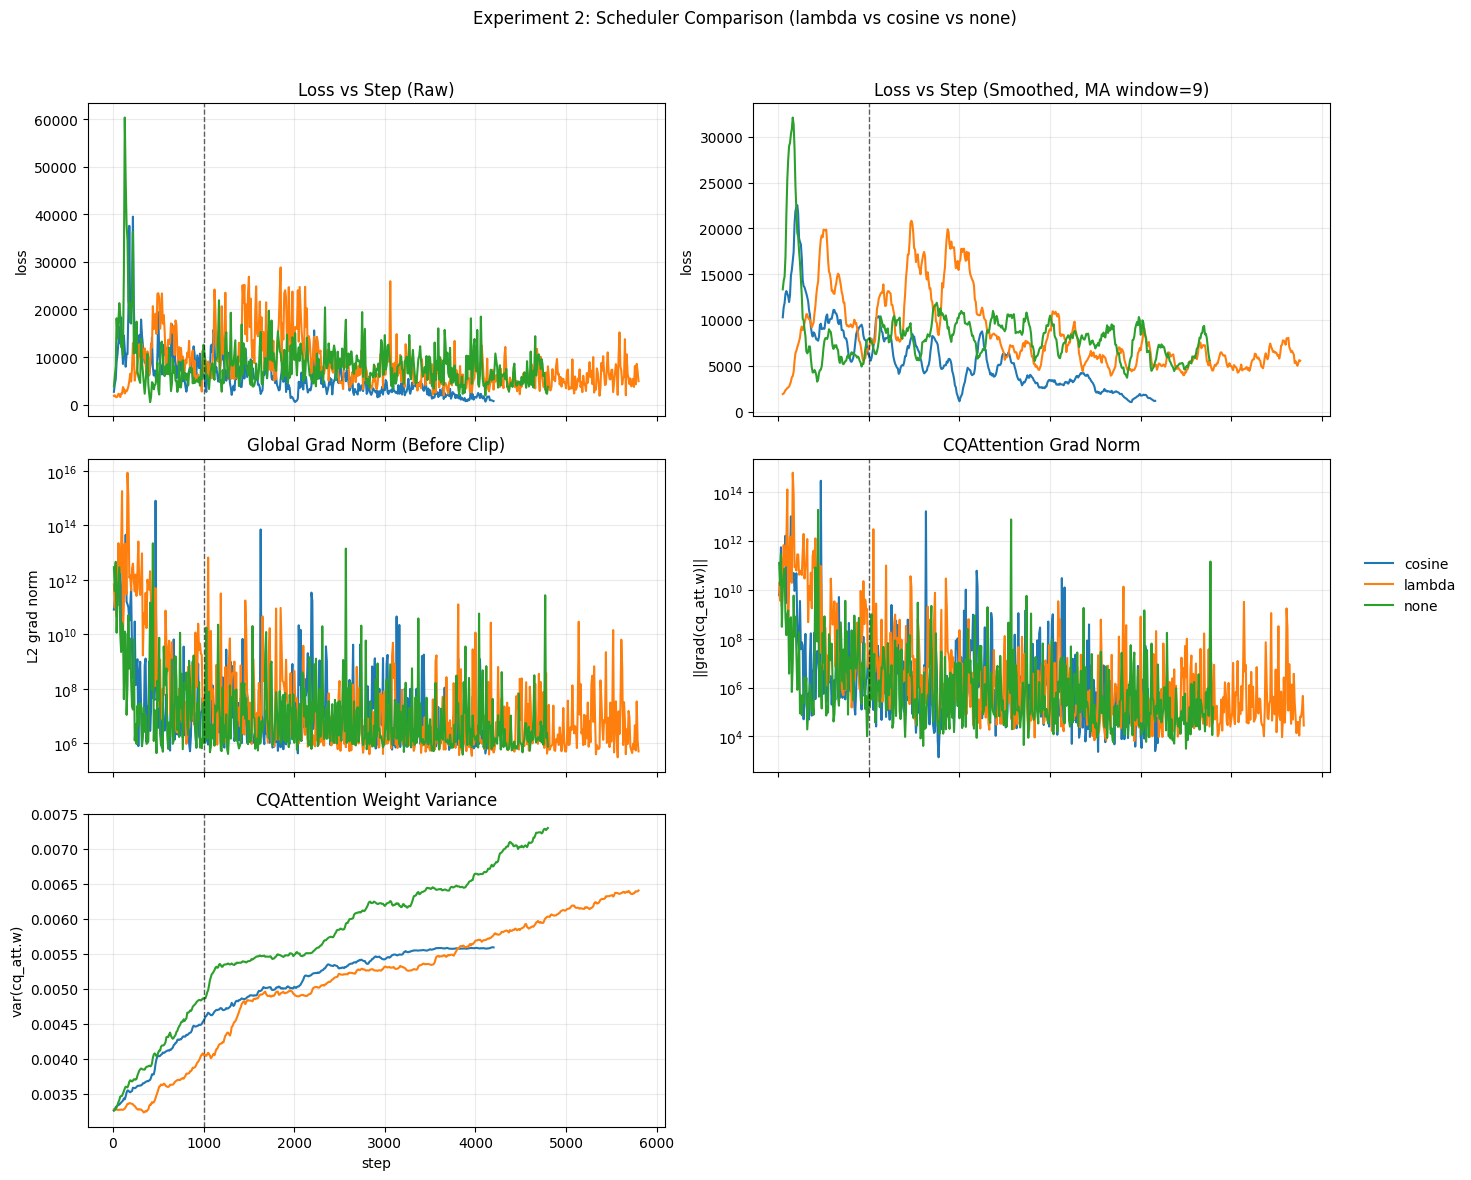

Loaded files:
- _log/exp2_cosine_seed42.json
- _log/exp2_lambda_seed42.json
- _log/exp2_none_seed42.json


In [ ]:
# Experiment 1 analysis: compact table + plots from _log/*.json
import glob
import json
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    HAVE_PANDAS = True
except Exception:
    HAVE_PANDAS = False

log_dir = "_log"
pattern = os.path.join(log_dir, "exp1_*_seed42.json")
files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(f"No files found for pattern: {pattern}")

# Load runs and infer scheduler name from filename
runs = {}
for path in files:
    name = os.path.basename(path).replace("exp1_", "").replace("_seed42.json", "")
    with open(path, "r") as f:
        data = json.load(f)
    runs[name] = data

required_cols = ["step", "loss", "lr", "grad_norm_before_clip", "cq_grad_norm", "cq_weight_var"]

# Build compact summary table
rows = []
for scheduler, records in runs.items():
    if not records:
        continue

    steps = np.array([r.get("step", np.nan) for r in records], dtype=float)
    loss = np.array([r.get("loss", np.nan) for r in records], dtype=float)
    gnorm = np.array([r.get("grad_norm_before_clip", np.nan) for r in records], dtype=float)
    cq_g = np.array([r.get("cq_grad_norm", np.nan) for r in records], dtype=float)
    cq_v = np.array([r.get("cq_weight_var", np.nan) for r in records], dtype=float)

    early = steps <= 1000
    late = steps > 1000

    # Non-finite event count across sampled rows
    nonfinite_count = sum(int(bool(r.get("nan_loss", False)) or bool(r.get("inf_loss", False)) or bool(r.get("nonfinite_grad", False))) for r in records)

    rows.append({
        "scheduler": scheduler,
        "num_logged_steps": int(np.isfinite(steps).sum()),
        "last_logged_step": int(np.nanmax(steps)),
        "early_loss_mean": float(np.nanmean(loss[early])) if np.any(early) else np.nan,
        "early_loss_std": float(np.nanstd(loss[early])) if np.any(early) else np.nan,
        "early_grad_mean": float(np.nanmean(gnorm[early])) if np.any(early) else np.nan,
        "early_grad_max": float(np.nanmax(gnorm[early])) if np.any(early) else np.nan,
        "early_cq_grad_mean": float(np.nanmean(cq_g[early])) if np.any(early) else np.nan,
        "cq_var_pre1000": float(np.nanmean(cq_v[early])) if np.any(early) else np.nan,
        "cq_var_post1000": float(np.nanmean(cq_v[late])) if np.any(late) else np.nan,
        "nonfinite_events": nonfinite_count,
    })

if HAVE_PANDAS:
    df = pd.DataFrame(rows).sort_values("scheduler").set_index("scheduler")
    display(df.round(6))
else:
    print("pandas not available. Compact summary:")
    for r in sorted(rows, key=lambda x: x["scheduler"]):
        print(r)


def moving_average(x, y, window=9):
    """Centered moving average for visualization."""
    if window <= 1 or len(y) < window:
        return x, y
    kernel = np.ones(window, dtype=float) / window
    y_smooth = np.convolve(y, kernel, mode="valid")
    half = window // 2
    x_smooth = x[half : len(x) - half]
    return x_smooth, y_smooth


# Comparative plots
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

for scheduler, records in sorted(runs.items()):
    if not records:
        continue
    x = np.array([r.get("step", np.nan) for r in records], dtype=float)
    y_loss = np.array([r.get("loss", np.nan) for r in records], dtype=float)
    y_grad = np.array([r.get("grad_norm_before_clip", np.nan) for r in records], dtype=float)
    y_cqg = np.array([r.get("cq_grad_norm", np.nan) for r in records], dtype=float)
    y_cqv = np.array([r.get("cq_weight_var", np.nan) for r in records], dtype=float)

    # Raw loss (full opacity)
    ax1.plot(x, y_loss, label=scheduler)

    # Smoothed loss (moving average)
    xs, ys = moving_average(x, y_loss, window=9)
    ax2.plot(xs, ys, label=scheduler)

    ax3.plot(x, y_grad, label=scheduler)
    ax4.plot(x, y_cqg, label=scheduler)
    ax5.plot(x, y_cqv, label=scheduler)

for ax in (ax1, ax2, ax3, ax4, ax5):
    ax.axvline(1000, color="k", linestyle="--", linewidth=1, alpha=0.6)
    ax.grid(alpha=0.25)

ax1.set_title("Loss vs Step (Raw)")
ax1.set_ylabel("loss")

ax2.set_title("Loss vs Step (Smoothed, MA window=9)")
ax2.set_ylabel("loss")

ax3.set_title("Global Grad Norm (Before Clip)")
ax3.set_ylabel("L2 grad norm")
ax3.set_yscale("log")

ax4.set_title("CQAttention Grad Norm")
ax4.set_ylabel("||grad(cq_att.w)||")
ax4.set_yscale("log")

ax5.set_title("CQAttention Weight Variance")
ax5.set_ylabel("var(cq_att.w)")

# Remove unused sixth subplot (raw+smoothed overlay removed)
ax6.axis("off")

ax5.set_xlabel("step")

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.905, 0.5), frameon=False)
fig.suptitle("Experiment 1: Scheduler Comparison (lambda vs cosine vs none)", y=0.98)
plt.tight_layout(rect=[0.0, 0.0, 0.90, 0.96])
plt.show()

print("Loaded files:")
for f in files:
    print("-", f)

## Experiment 2 — Impact of Normalization Topologies on Depthwise Convolutions

Compares `layer_norm` (control) vs `group_norm` (intervention) while keeping all other settings fixed.

Outputs:
- Final best Dev F1 / EM from each run
- Per-step diagnostics saved to `_log/exp2_layer_seed42.json` and `_log/exp2_group_seed42.json`
- Conv-layer gradient norms (`conv_grad_norm`) for stability analysis over the first 2000 steps

In [ ]:
from TrainTools.train import train

exp2_common = dict(
    train_npz="_data/train.npz",
    dev_npz="_data/dev.npz",
    word_emb_json="_data/word_emb.json",
    char_emb_json="_data/char_emb.json",
    train_eval_json="_data/train_eval.json",
    dev_eval_json="_data/dev_eval.json",
    log_dir="_log",

    # Match Section 3 baseline training recipe
    num_steps=10000,
    checkpoint=1500,
    batch_size=8,
    accumulate_grad_steps=4,
    seed=42,
    val_num_batches=0,
    test_num_batches=150,

    # Optimizer hyperparameters
    learning_rate=1e-3,
    beta1=0.8,
    beta2=0.999,
    eps=1e-7,
    weight_decay=3e-5,
    early_stop=10,

    optimizer_name="adam",
    scheduler_name="lambda",
    loss_name="qa_ce",
    log_every_steps=10,
    save_step_metrics=True,
    track_cq_stats=True,
    track_conv_stats=True,
)

r_layer = train(
    **exp2_common,
    save_dir="_model/exp1_layer",
    ckpt_name="model.pt",
    norm_name="layer_norm",
    step_metrics_file="exp2_layer_seed42.json",
)

r_group = train(
    **exp2_common,
    save_dir="_model/exp1_group",
    ckpt_name="model.pt",
    norm_name="group_norm",
    norm_groups=8,
    step_metrics_file="exp2_group_seed42.json",
)

print("Experiment 2 training-stage best metrics")
print(f"layer_norm -> Best F1: {r_layer['best_f1']:.4f} | Best EM: {r_layer['best_em']:.4f}")
print(f"group_norm -> Best F1: {r_group['best_f1']:.4f} | Best EM: {r_group['best_em']:.4f}")

  2%|▏         | 4/200 [00:26<21:25,  6.56s/it]


KeyboardInterrupt: 

In [ ]:
import argparse
import os
import torch
import ujson as json

from Data import SQuADDataset, load_dev_eval, load_word_char_mats
from Losses import losses
from Models import QANet
from EvaluateTools.eval_utils import run_eval

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_from_ckpt(
    save_dir,
    ckpt_name="model.pt",
    dev_npz="_data/dev.npz",
    word_emb_json="_data/word_emb.json",
    char_emb_json="_data/char_emb.json",
    dev_eval_json="_data/dev_eval.json",
    batch_size=8,
    test_num_batches=-1,
    loss_name="qa_ce",
    log_dir="_log",
):
    os.makedirs(log_dir, exist_ok=True)
    ckpt_path = os.path.join(save_dir, ckpt_name)

    # Works with PyTorch 2.6 checkpoints that include scheduler lambda objects.
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg = ckpt.get("config", {})

    args = argparse.Namespace(
        dev_npz=dev_npz,
        word_emb_json=word_emb_json,
        char_emb_json=char_emb_json,
        dev_eval_json=dev_eval_json,
        para_limit=int(cfg.get("para_limit", 400)),
        ques_limit=int(cfg.get("ques_limit", 50)),
        char_limit=int(cfg.get("char_limit", 16)),
        d_model=int(cfg.get("d_model", 96)),
        num_heads=int(cfg.get("num_heads", 8)),
        glove_dim=int(cfg.get("glove_dim", 300)),
        char_dim=int(cfg.get("char_dim", 64)),
        dropout=float(cfg.get("dropout", 0.1)),
        dropout_char=float(cfg.get("dropout_char", 0.05)),
        pretrained_char=bool(cfg.get("pretrained_char", False)),
        norm_name=str(cfg.get("norm_name", "layer_norm")),
        norm_groups=int(cfg.get("norm_groups", 8)),
        activation=str(cfg.get("activation", "relu")),
        init_name=str(cfg.get("init_name", "kaiming")),
    )

    word_mat, char_mat = load_word_char_mats(args)
    model = QANet(word_mat, char_mat, args).to(DEVICE)
    model.load_state_dict(ckpt["model"])

    dev_eval = load_dev_eval(args)
    dev_dataset = SQuADDataset(dev_npz)

    metrics, ans = run_eval(
        model, dev_dataset, dev_eval,
        num_batches=test_num_batches,
        batch_size=batch_size,
        use_random_batches=False,
        device=DEVICE,
        loss_fn=losses[loss_name],
    )

    with open(os.path.join(log_dir, "answers.json"), "w") as f:
        json.dump(ans, f)

    return {"f1": metrics["f1"], "exact_match": metrics["exact_match"], "loss": metrics["loss"]}

# Full-dev inference for each separately saved checkpoint
m_layer = evaluate_from_ckpt(save_dir="_model/exp1_layer", ckpt_name="model.pt")
m_group = evaluate_from_ckpt(save_dir="_model/exp1_group", ckpt_name="model.pt")

print("Experiment 2 full-dev checkpoint evaluation")
print(f"layer_norm -> F1: {m_layer['f1']:.4f} | EM: {m_layer['exact_match']:.4f} | Loss: {m_layer['loss']:.6f}")
print(f"group_norm -> F1: {m_group['f1']:.4f} | EM: {m_group['exact_match']:.4f} | Loss: {m_group['loss']:.6f}")

,norm,num_points_<=10000,last_logged_step_<=10000,loss_mean_<=10000,global_grad_mean_<=10000,conv_grad_mean_<=10000,conv_grad_std_<=10000,conv_grad_max_<=10000
1,group_norm,1000,10000,5823.382401,6.778901e+11,3.053553e+11,6.773676e+12,2.106255e+14
0,layer_norm,1000,10000,6838.137567,1.033516e+11,4.389759e+10,4.014023e+11,8.013133e+12


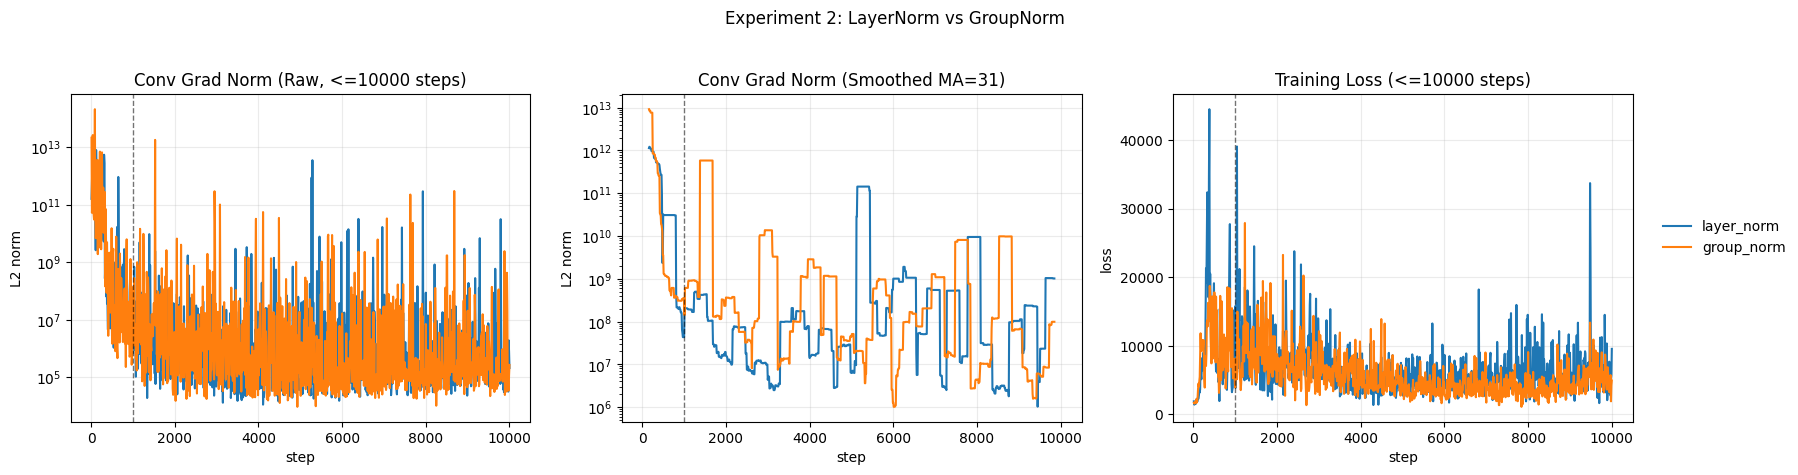

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    HAVE_PANDAS = True
except Exception:
    HAVE_PANDAS = False


def load_step_metrics(path):
    with open(path, "r") as f:
        return json.load(f)


log_dir = "_log"
files = {
    "layer_norm": os.path.join(log_dir, "exp2_layer_seed42.json"),
    "group_norm": os.path.join(log_dir, "exp2_group_seed42.json"),
}

runs = {}
for name, path in files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing metrics file: {path}")
    runs[name] = load_step_metrics(path)

# Plot full experiment horizon
max_step = 10000

summary_rows = []
for name, records in runs.items():
    rec = [r for r in records if r.get("step", 0) <= max_step]
    steps = np.array([r.get("step", np.nan) for r in rec], dtype=float)
    loss = np.array([r.get("loss", np.nan) for r in rec], dtype=float)
    g_all = np.array([r.get("grad_norm_before_clip", np.nan) for r in rec], dtype=float)
    g_conv = np.array([r.get("conv_grad_norm", np.nan) for r in rec], dtype=float)

    summary_rows.append({
        "norm": name,
        "num_points_<=10000": int(np.isfinite(steps).sum()),
        "last_logged_step_<=10000": int(np.nanmax(steps)) if len(steps) else np.nan,
        "loss_mean_<=10000": float(np.nanmean(loss)) if len(loss) else np.nan,
        "global_grad_mean_<=10000": float(np.nanmean(g_all)) if len(g_all) else np.nan,
        "conv_grad_mean_<=10000": float(np.nanmean(g_conv)) if len(g_conv) else np.nan,
        "conv_grad_std_<=10000": float(np.nanstd(g_conv)) if len(g_conv) else np.nan,
        "conv_grad_max_<=10000": float(np.nanmax(g_conv)) if len(g_conv) else np.nan,
    })

if HAVE_PANDAS:
    display(pd.DataFrame(summary_rows).sort_values("norm").round(6))
else:
    print("pandas not available. Summary:")
    for row in sorted(summary_rows, key=lambda x: x["norm"]):
        print(row)


def moving_average(x, y, window=9):
    if window <= 1 or len(y) < window:
        return x, y
    kernel = np.ones(window, dtype=float) / window
    y_s = np.convolve(y, kernel, mode="valid")
    half = window // 2
    x_s = x[half: len(x) - half]
    return x_s, y_s


fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
ax1, ax2, ax3 = axes

for name, records in runs.items():
    rec = [r for r in records if r.get("step", 0) <= max_step]
    x = np.array([r.get("step", np.nan) for r in rec], dtype=float)
    y_conv = np.array([r.get("conv_grad_norm", np.nan) for r in rec], dtype=float)
    y_all = np.array([r.get("grad_norm_before_clip", np.nan) for r in rec], dtype=float)
    y_loss = np.array([r.get("loss", np.nan) for r in rec], dtype=float)

    ax1.plot(x, y_conv, label=name)
    xs, ys = moving_average(x, y_conv, window=31)
    ax2.plot(xs, ys, label=name)
    ax3.plot(x, y_loss, label=name)

for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.25)
    ax.axvline(1000, color="k", linestyle="--", linewidth=1, alpha=0.55)

ax1.set_title("Conv Grad Norm (Raw, <=10000 steps)")
ax1.set_ylabel("L2 norm")
ax1.set_yscale("log")

ax2.set_title("Conv Grad Norm (Smoothed MA=31)")
ax2.set_ylabel("L2 norm")
ax2.set_yscale("log")

ax3.set_title("Training Loss (<=10000 steps)")
ax3.set_ylabel("loss")

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("step")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
fig.suptitle("Experiment 2: LayerNorm vs GroupNorm")
plt.tight_layout(rect=[0.0, 0.0, 0.92, 0.95])
plt.show()

if "r_layer" in globals() and "r_group" in globals():
    print("Run-level best metrics during training:")
    print(f"layer_norm -> Best F1: {r_layer['best_f1']:.4f} | Best EM: {r_layer['best_em']:.4f}")
    print(f"group_norm -> Best F1: {r_group['best_f1']:.4f} | Best EM: {r_group['best_em']:.4f}")

if "m_layer" in globals() and "m_group" in globals():
    print("\nFull-dev checkpoint evaluation metrics:")
    print(f"layer_norm -> F1: {m_layer['f1']:.4f} | EM: {m_layer['exact_match']:.4f} | Loss: {m_layer['loss']:.6f}")
    print(f"group_norm -> F1: {m_group['f1']:.4f} | EM: {m_group['exact_match']:.4f} | Loss: {m_group['loss']:.6f}")